# Spotify Dataset Analysis - Bad Bunny

In [2]:
!pip install gdown -q


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os

DATA_FILE = 'tracks_features.csv'

if not os.path.exists(DATA_FILE):
    print('Downloading dataset...')
    !gdown 1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI
else:
    print(f'{DATA_FILE} already exists, skipping download.')

tracks_features.csv already exists, skipping download.


In [4]:
import warnings
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='tab10')

In [5]:
df = pd.read_csv(DATA_FILE)
AUDIO_FEATURES = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence'
]

print('Missing values:')
print(df[AUDIO_FEATURES].isnull().sum())
print()
df[AUDIO_FEATURES].describe()

Missing values:
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
dtype: int64



,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,4.467511e-01,4.930565e-01,2.488399e+05,5.095363e-01,2.828605e-01,2.015994e-01,-1.180870e+01,8.438219e-02,1.176344e+02,4.279866e-01
std,3.852014e-01,1.896694e-01,1.622104e+05,2.946839e-01,3.762844e-01,1.804591e-01,6.982132e+00,1.159914e-01,3.093705e+01,2.704846e-01
min,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.760000e-02,3.560000e-01,1.740900e+05,2.520000e-01,7.600000e-06,9.680000e-02,-1.525400e+01,3.510000e-02,9.405400e+01,1.910000e-01
50%,3.890000e-01,5.010000e-01,2.243390e+05,5.240000e-01,8.080000e-03,1.250000e-01,-9.791000e+00,4.460000e-02,1.167260e+02,4.030000e-01
75%,8.610000e-01,6.330000e-01,2.858400e+05,7.660000e-01,7.190000e-01,2.450000e-01,-6.717000e+00,7.230000e-02,1.370460e+02,6.440000e-01
max,9.960000e-01,1.000000e+00,6.061090e+06,1.000000e+00,1.000000e+00,1.000000e+00,7.234000e+00,9.690000e-01,2.489340e+02,1.000000e+00


In [6]:
TARGET_ARTIST_ID = '4q3ewBCX7sLwd24euuV69X'  # Bad Bunny

def artist_id_in_list(artist_ids_str: str, target_id: str) -> bool:
    try:
        return target_id in ast.literal_eval(artist_ids_str)
    except (ValueError, SyntaxError):
        return False

mask = df['artist_ids'].apply(lambda x: artist_id_in_list(str(x), TARGET_ARTIST_ID))
artist_df = df[mask].copy()

print(f'Total rows found: {len(artist_df)}')
artist_df[['name', 'album', 'release_date', 'year'] + AUDIO_FEATURES].head()

Total rows found: 86


,name,album,release_date,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
90608,Solo de Mi,Solo de Mi,2018-12-14,2018,0.2870,0.743,197968,0.730,0.000081,0.0778,-4.314,0.1250,179.972,0.150
634641,Cántalo,PAUSA,2020-05-28,2020,0.0339,0.708,218996,0.795,0.000000,0.3620,-4.710,0.1150,95.041,0.734
724821,Krippy Kush (feat. 21 Savage & Rvssian) - Remix,Krippy Kush (feat. 21 Savage & Rvssian) [Remix],2017-11-21,2017,0.0512,0.743,237160,0.671,0.000000,0.1160,-5.241,0.1220,163.229,0.499
758363,MIA (feat. Drake),MIA (feat. Drake),2018-10-11,2018,0.0141,0.817,210368,0.539,0.000496,0.0990,-6.349,0.0621,97.062,0.158
761464,Te Boté - Remix,Te Boté (Remix),2018-04-13,2018,0.5420,0.903,417920,0.675,0.000013,0.0595,-3.445,0.2140,96.507,0.442


In [7]:
# Diagnóstico: álbumes presentes en el dataset
artist_df['short_album_name'] = artist_df['album'].str.split('(').str[0].str.strip()

diag = (
    artist_df
    .groupby('short_album_name')
    .agg(tracks=('name', 'count'), year=('year', 'min'))
    .sort_values('year')
)
print('Albums found in the dataset:')
print(diag.to_string())

Albums found in the dataset:
                                            tracks  year
short_album_name                                        
47                                               1  2017
Krippy Kush                                      1  2017
Mayores                                          1  2017
Tu No Metes Cabra Remix                          1  2017
La Fama Que Camina                               1  2018
La Oscuridad                                     1  2018
Invasion of Privacy                              2  2018
25/7                                             1  2018
Los Campeones del Pueblo "The Big Leagues"       1  2018
X 100PRE                                        15  2018
Solo de Mi                                       1  2018
Thinkin                                          1  2018
Satisfacción                                     1  2018
Te Boté                                          1  2018
Más de un Siglo                                  1  2018
MI

In [8]:
STUDIO_ALBUMS = {
    'X 100PRE',
    'YHLQMDLG',
    'EL ÚLTIMO TOUR DEL MUNDO',
    #'LAS QUE NO IBAN A SALIR' # Album recopilatorio
}

artist_df = artist_df[artist_df['short_album_name'].isin(STUDIO_ALBUMS)]

artist_df = (
    artist_df
    .sort_values('year')
    .drop_duplicates(subset=['short_album_name', 'name'], keep='first')
    .sort_values('year')
    .reset_index(drop=True)
)

ALBUM_ORDER = (
    artist_df
    .drop_duplicates('short_album_name')
    .sort_values('year')['short_album_name']
    .tolist()
)

print(f'Tracks after cleaning: {len(artist_df)}')
print('Albums (chronological):', ALBUM_ORDER)

Tracks after cleaning: 50
Albums (chronological): ['X 100PRE', 'YHLQMDLG', 'EL ÚLTIMO TOUR DEL MUNDO']


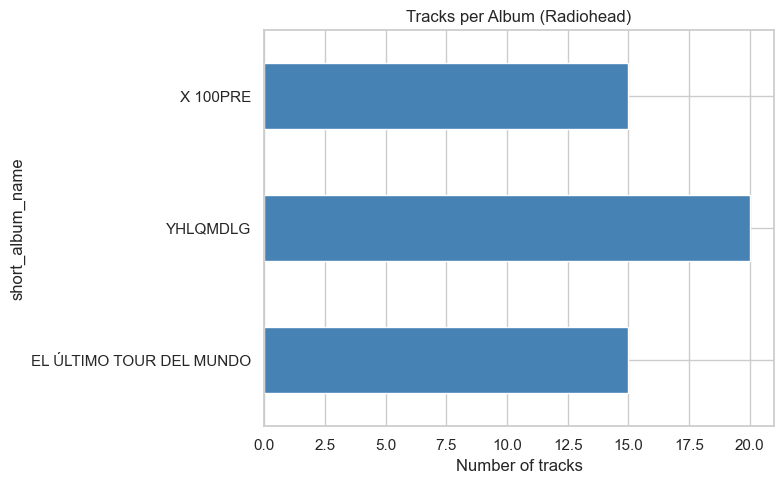

In [9]:
track_counts = (
    artist_df.groupby('short_album_name')['name']
    .count()
    .loc[ALBUM_ORDER]
)
track_counts.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.xlabel('Number of tracks')
plt.title('Tracks per Album (Radiohead)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

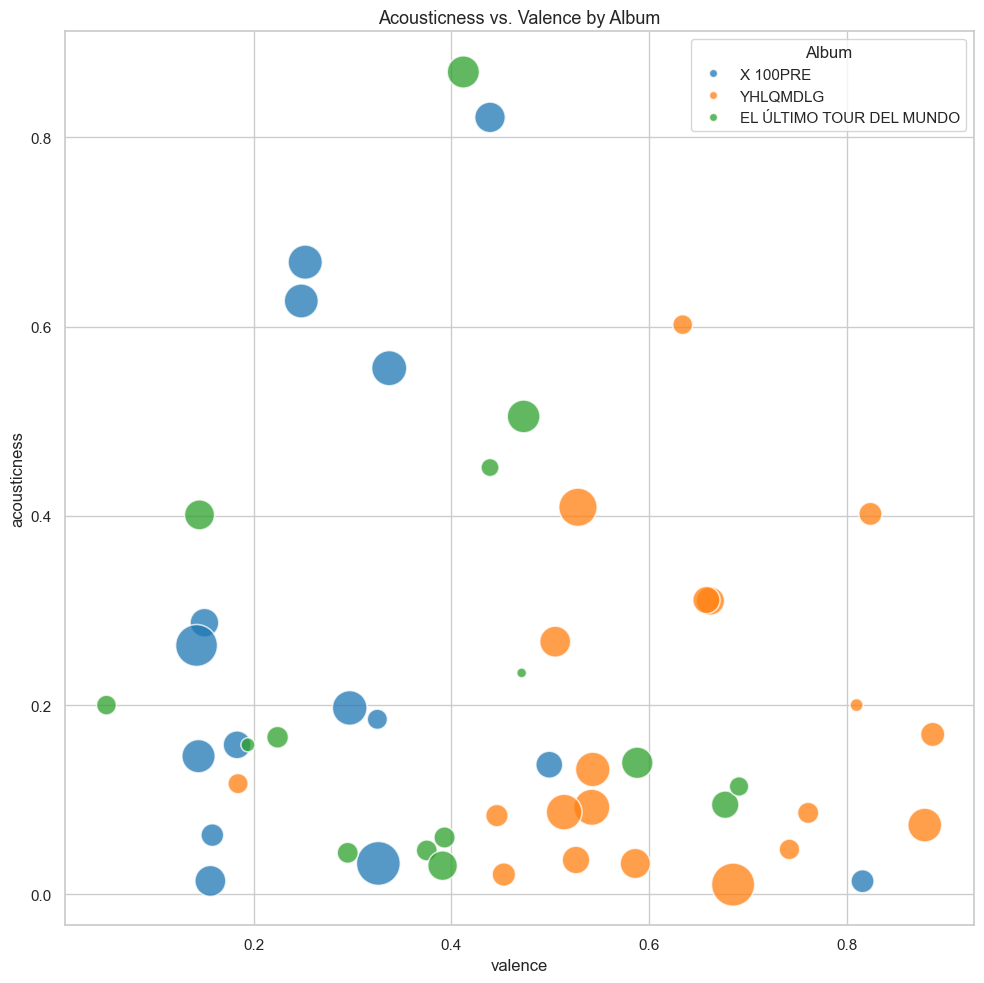

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    data=artist_df, x='valence', y='acousticness',
    hue='short_album_name', hue_order=ALBUM_ORDER,
    palette='tab10', size='duration_ms', sizes=(50, 1000),
    alpha=0.75, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
n = len(ALBUM_ORDER)
ax.legend(handles[1:n+1], labels[1:n+1], title='Album', loc='best')
ax.set_title('Acousticness vs. Valence by Album', fontsize=13)
plt.tight_layout()
plt.show()

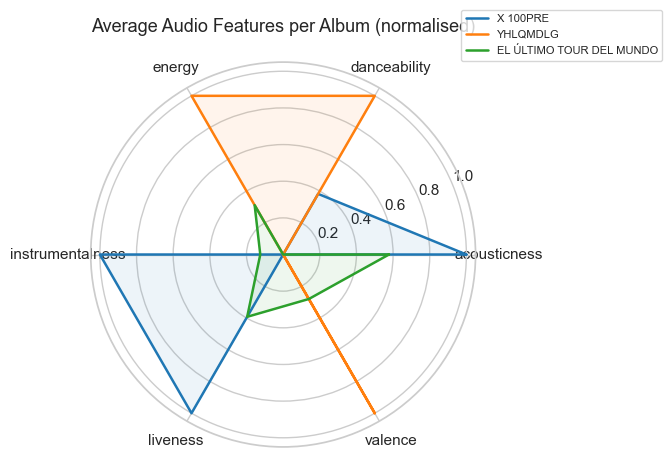

In [11]:
RADAR_FEATURES = ['acousticness', 'danceability', 'energy',
                  'instrumentalness', 'liveness', 'valence']

album_means = artist_df.groupby('short_album_name')[RADAR_FEATURES].mean().loc[ALBUM_ORDER]
album_norm  = (album_means - album_means.min()) / (album_means.max() - album_means.min() + 1e-9)

N      = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors  = sns.color_palette('tab10', n_colors=len(album_norm))

for (album, row), color in zip(album_norm.iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=1.8, label=album)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_FEATURES, size=11)
ax.set_title('Average Audio Features per Album (normalised)', size=13, pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

## Analisis de letras de canciones

In [12]:
import requests

def get_lyrics(artist, title):
    url = f"https://api.lyrics.ovh/v1/{artist}/{title}"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            return data.get("lyrics", "")
        else:
            return ""
    except:
        return ""

artist_df['lyrics'] = artist_df.apply(
    lambda row: get_lyrics('Bad Bunny', row['name']),
    axis=1
)

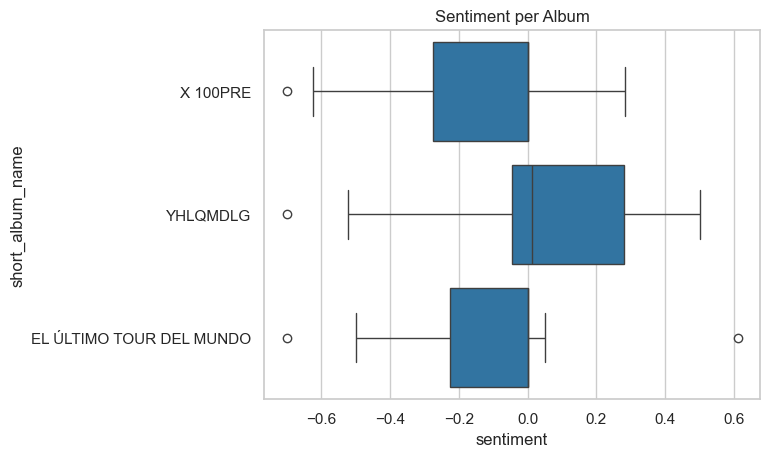

In [13]:
from textblob import TextBlob

def get_sentiment(text):
    if not text:
        return 0
    return TextBlob(text).sentiment.polarity

artist_df['sentiment'] = artist_df['lyrics'].apply(get_sentiment)

sns.boxplot(
    data=artist_df,
    x='sentiment',
    y='short_album_name',
    order=ALBUM_ORDER
)
plt.title('Sentiment per Album')
plt.show()

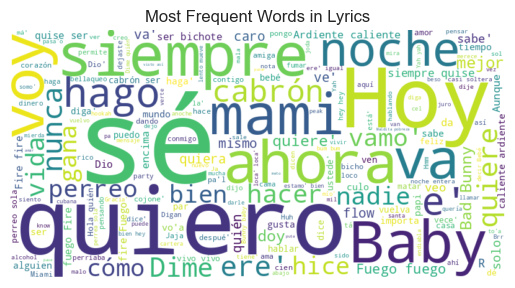

In [20]:
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
import nltk

#nltk.download('stopwords')

# Stopwords en español + inglés
stopwords_es = set(stopwords.words('spanish'))
stopwords_en = set(stopwords.words('english'))

# Palabras vacías típicas en canciones
custom_stopwords = {
    'yeah', 'eh', 'oh', 'pa\'', 'na', 'nah',
    'na\'', 'to\'', 'te', 'yo', 'ey', 'yeh',
    'si', 'prr', 'uh', 'wuh', 'lo\'', 'ah'
}

all_stopwords = stopwords_es.union(stopwords_es).union(custom_stopwords).union(stopwords_en)

# Texto total
text = " ".join(artist_df['lyrics'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=all_stopwords
).generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Lyrics')
plt.show()

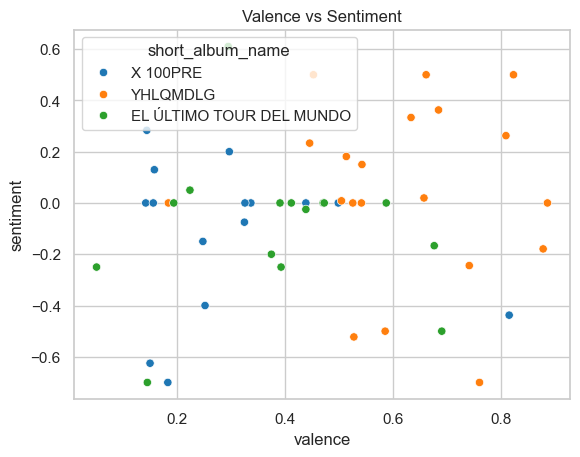

In [15]:
sns.scatterplot(
    data=artist_df,
    x='valence',
    y='sentiment',
    hue='short_album_name'
)
plt.title('Valence vs Sentiment')
plt.show()